# Computed Tomography and Tomosynthesis

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.transform import iradon
from skimage.transform import iradon_sart

# load a sinogram of a simple phantom of the head
sino = np.load('data/medical/Schepp_Logan_sinogram 1.npy')
# make a filtered back projection reconstruction
theta = np.linspace(0.0, 180.0, max(sino.shape), endpoint=False)
reconstruction_fbp = iradon(sino, theta=theta, filter_name='ramp')
# make a reconstruction with Simultaneous Algebraic Reconstruction Technique
reconstruction_sart = iradon_sart(sino, theta=theta)
# plot with matplotlib
fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(9, 5), sharex=True, sharey=True)
ax1.set_title("Sinogram")
ax1.imshow(sino, cmap=plt.cm.Greys_r,)
ax2.set_title("Reconstruction\nFiltered back projection")
ax2.imshow(reconstruction_fbp, cmap=plt.cm.Greys_r)
ax3.set_title("Reconstruction\nSART")
ax3.imshow(reconstruction_sart, cmap=plt.cm.Greys_r)
ax4.set_title("Difference\n between reconstructions")
ax4.imshow(reconstruction_sart - reconstruction_fbp, cmap=plt.cm.Greys_r)

plt.show()

ValueError: This file contains pickled (object) data. If you trust the file you can load it unsafely using the `allow_pickle=` keyword argument or `pickle.load()`.

## Magnetic Resonance Imaging

### An example of a k-space transform

In [2]:
slice_kspace = np.load('data/medical/slice_kspace.npy')
# show shape
print(slice_kspace.shape)
# show type
print(type(slice_kspace))
# print type of an example pixel
print(type(slice_kspace[3,3]))

(64, 64)
<class 'numpy.ndarray'>
<class 'numpy.complex128'>


### Extract and graph the real and imaginary parts

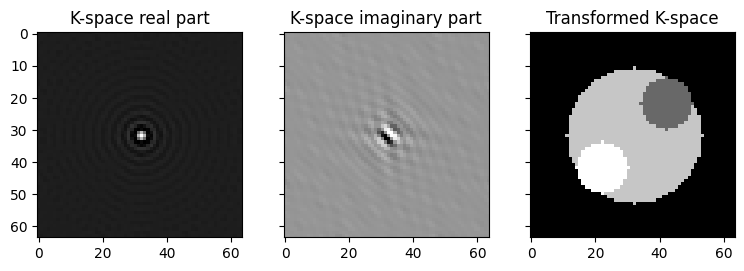

In [3]:
real_from_slice_kspace = slice_kspace.real
imaginary_from_slice_kspace = slice_kspace.imag
# make an inverse fourier
def inverse_fft2_shift(kspace):
    return np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(kspace, axes=(-2,-1)), norm='ortho'),axes=(-2,-1))
# graph both    
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(9, 5), sharex=True, sharey=True)
ax1.set_title("K-space real part")
ax1.imshow(real_from_slice_kspace, cmap=plt.cm.Greys_r,)
ax2.set_title("K-space imaginary part")
ax2.imshow(imaginary_from_slice_kspace, cmap=plt.cm.Greys_r,)
ax3.set_title("Transformed K-space")
ax3.imshow(np.abs(inverse_fft2_shift(slice_kspace)), cmap=plt.cm.Greys_r)